# 03.1 — Feature Engineering (Light)

This notebook is split in two, by compute requirement rather than by section number:

- **This notebook (`03.1`)** computes every feature that only needs a CPU — word frequency, TF-IDF, sentiment (TextBlob/VADER/Gemini), rhetorical means, adjective/adverb ratio, readability, and evidence use. It runs anywhere: a plain local Python environment or Colab, no GPU required.
- **`03.2_feature_engineering_heavy.ipynb`** computes the features that need a GPU to run in reasonable time — RoBERTa and BART/XLM-RoBERTa classification, and BERT document embeddings — and is best run in Colab with a GPU runtime.

`03.2` loads this notebook's output and continues from there, so **run this notebook first**.

> Loads from `results/02_comments_df_base.csv` (output of `02_data_annotation.ipynb`).
> If running from a fresh clone (e.g. in Colab), only the zipped version `results/02_comments_df_base.csv.zip` is tracked in git — it's loaded automatically as a fallback.


In [2]:
import pandas as pd, zipfile, os

base_csv = '../results/02_comments_df_base.csv'
base_zip = '../results/02_comments_df_base.csv.zip'

if os.path.exists(base_csv):
    comments_df = pd.read_csv(base_csv)
    print('Loaded from 02_comments_df_base.csv')
else:
    with zipfile.ZipFile(base_zip) as z:
        comments_df = pd.read_csv(z.open(z.namelist()[0]))
    print('Loaded from 02_comments_df_base.csv.zip')

print(comments_df.shape)

separator_token = "[SEP]"  # marks the boundary between thread text and final comment when concatenated


Loaded from 02_comments_df_base.csv
(3973, 8)


# ５. Inspecting the Comments DataSet

## 5.1 Words Frequency

Let's see what are the common words in convincing and not-convincing comments:

In [3]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
import string

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
stop_words = {w.translate(str.maketrans("", "", string.punctuation)) for w in stop_words}  # match punctuation-stripped tokens below (e.g. "dont" for "don't")

# Function to clean text and count words
def get_most_common_words(thread_texts, final_comments, n=20):
    text = " ".join(final_comments)
    # text = " ".join(thread_texts) + " ".join(final_comments)
    words = text.lower().translate(str.maketrans("", "", string.punctuation)).split()
    words = [word for word in words if word not in stop_words]
    # remove single digits, punctuation charcters and single letters:

    return Counter(words).most_common(n)

comments_df["cleaned_thread_text"] = comments_df["cleaned_thread_text"].fillna("")
comments_df["cleaned_final_comment"] = comments_df["cleaned_final_comment"].fillna("")

# Most common words in persuasive arguments
convincing = comments_df[comments_df["is_convincing"] == 1]
persuasive_words = get_most_common_words(convincing['cleaned_thread_text'], convincing["cleaned_final_comment"])
print("Most common words in persuasive arguments:", persuasive_words)

# Most common words in unconvincing arguments
not_convincing = comments_df[comments_df["is_convincing"] == 0]
unconvincing_words = get_most_common_words(not_convincing['cleaned_thread_text'], not_convincing["cleaned_final_comment"])
print("Most common words in unconvincing arguments:", unconvincing_words)


Most common words in persuasive arguments: [('people', 1014), ('would', 592), ('like', 499), ('think', 454), ('one', 386), ('even', 326), ('get', 314), ('also', 275), ('way', 256), ('want', 248), ('make', 247), ('us', 242), ('time', 240), ('much', 236), ('say', 227), ('many', 224), ('things', 223), ('thats', 203), ('going', 203), ('see', 202)]
Most common words in unconvincing arguments: [('people', 1755), ('would', 1209), ('think', 903), ('like', 877), ('one', 687), ('even', 586), ('also', 546), ('get', 545), ('make', 493), ('way', 483), ('thats', 480), ('time', 463), ('much', 452), ('could', 442), ('know', 412), ('want', 410), ('point', 408), ('say', 405), ('really', 396), ('someone', 381)]


[nltk_data] Downloading package stopwords to /Users/dikla/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


We see that in both convincing and unconvincing comments the most common words list is very similar, so it does not provide any meaningful insights.

## 5.2 TF-IDF


TF-IDF or Word2Vec to compare persuasive vs. unconvincing arguments.

In [4]:
def get_comment_and_thread(comment_first=False, is_convincing=None, include_sep=True):
  if is_convincing is not None:
    df = comments_df[comments_df["is_convincing"] == is_convincing]
  else:
    df = comments_df

  if include_sep:
    sep = "\n" + separator_token + "\n"
  else:
    sep = "\n"

  if comment_first:
    return df['final_comment'] + sep + df['thread_text'].fillna("")

  return df['thread_text'].fillna("") + sep + df['final_comment']

In [5]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

def get_top_tfidf_words(texts, top_n=10):
    """Compute TF-IDF and return the top N words with highest scores."""
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()

    # Compute the max TF-IDF score for each word across all documents
    max_tfidf_scores = np.max(tfidf_matrix.toarray(), axis=0)

    # Get indices of the top N words
    top_indices = np.argsort(max_tfidf_scores)[::-1][:top_n]

    # Retrieve the words and their scores
    top_words = [(feature_names[i], max_tfidf_scores[i]) for i in top_indices]
    return top_words



top_words_all = get_top_tfidf_words(get_comment_and_thread(include_sep=False))  # we don't want the separator to be included in the tf-idf calculation
print("Top 10 words in the entire dataset:", top_words_all)

convincing_texts = get_comment_and_thread(is_convincing=1, include_sep=False)
top_words_convincing = get_top_tfidf_words(convincing_texts)
print("\nTop 10 words in convincing comments:", top_words_convincing)

non_convincing_texts = get_comment_and_thread(is_convincing=0, include_sep=False)
top_words_non_convincing = get_top_tfidf_words(non_convincing_texts)
print("\nTop 10 words in non-convincing comments:", top_words_non_convincing)


Top 10 words in the entire dataset: [('suspiciouslyspecific', np.float64(1.0)), ('good', np.float64(1.0)), ('delta', np.float64(1.0)), ('yes', np.float64(1.0)), ('logistics', np.float64(1.0)), ('blank', np.float64(1.0)), ('source', np.float64(1.0)), ('agree', np.float64(1.0)), ('right', np.float64(1.0)), ('themonkeyspaw', np.float64(1.0))]

Top 10 words in convincing comments: [('la', np.float64(0.7796031655183068)), ('chugga', np.float64(0.7626626421349926)), ('organizers', np.float64(0.7071067811865475)), ('reenactment', np.float64(0.7071067811865475)), ('dog', np.float64(0.6795135126588502)), ('disney', np.float64(0.6644333537194596)), ('autisum', np.float64(0.6631323385808545)), ('offended', np.float64(0.6629148964956889)), ('culture', np.float64(0.6562246031356688)), ('btw', np.float64(0.6497722540930019))]

Top 10 words in non-convincing comments: [('themonkeyspaw', np.float64(1.0)), ('suspiciouslyspecific', np.float64(1.0)), ('agree', np.float64(1.0)), ('delta', np.float64(1.0))

We can see that the results are not very meaningful. It makes sense that the list of high-score TF-IDF does not provide much insight, because this forum includes posts in various subjects and for each subject probably different words are used.

We hoped to see some words that may be used in multiple convincing examples, but we see that it is not the case.

## Shared utilities

Helper functions reused by several sections below (their natural "home" section is in `03.2`, since that's where they're first needed there too, but the light sections here need them first).

In [6]:
import re
def do_calc_feature(feature, func, remove_urls=False, switch_order=False):
  for index, row in comments_df.iterrows():
    if pd.isna(row[feature]):  # calculate only if wasn't calculated yet
      print(f"Calculating {feature} for index {index}")
      if not isinstance(row['thread_text'], str):
        text = row['final_comment']
      elif switch_order:
        text = row['final_comment'] + "\n" + row['thread_text']
      else:
        text = row['thread_text'] + "\n" + row['final_comment']

      if remove_urls:
        text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
      comments_df.at[index, feature] = func(text)

In [7]:
import re
def do_calc_feature_op(feature, func, remove_urls=False):
  for index, row in op_df.iterrows():
    if pd.isna(row[feature]):  # calculate only if wasn't calculated yet
      print(f"Calculating {feature} for index {index}")
      text = row['original_post']

      if remove_urls:
        text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
      op_df.at[index, feature] = func(text)

In [8]:
import matplotlib.pyplot as plt

def plot_category_histogram(df, column_name, display_name):
    """
    Plots a histogram showing the distribution of convincing and non-convincing comments for each category in the specified column.

    Args:
        df: The pandas DataFrame containing the data.
        column_name: The name of the column containing the categories.
    """

    convincing_counts = df[df['is_convincing'] == 1][column_name].value_counts()
    non_convincing_counts = df[df['is_convincing'] == 0][column_name].value_counts()

    categories = convincing_counts.index.union(non_convincing_counts.index)
    convincing_counts = convincing_counts.reindex(categories, fill_value=0)
    non_convincing_counts = non_convincing_counts.reindex(categories, fill_value=0)

    width = 0.4
    x = range(len(categories))
    fig, ax = plt.subplots(figsize=(12,6))
    rects1 = ax.bar([i - width/2 for i in x], convincing_counts, width, label='Convincing', color='green')
    rects2 = ax.bar([i + width/2 for i in x], non_convincing_counts, width, label='Non-Convincing', color='red')

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate('{}'.format(height),
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')
    autolabel(rects1)
    autolabel(rects2)

    ax.set_xlabel(display_name)
    ax.set_ylabel('Number of Comments')
    ax.set_title(f'Number of Convincing and Non-Convincing Comments per {display_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# ６. Feature engineering


We would like to find the characteristics of convincing arguments. We will create several features that can be helpful in identifying a convincing argument, and the new features can later be used in a predictive model.

In [9]:
untrusted_features = []  # feature names we don't trust; saved to results/untrusted_features.json for 04_model_training.ipynb to run with/without


## 6.1 Sentiment Analysis

Check whether sentiment (positive/negative tone) correlates with persuasiveness

### TextBlob

In [10]:
def concatenate_columns(df):
  """
  Concatenates 'thread_text' and 'final_comment' columns with a space in between.

  Args:
    df: pandas DataFrame with 'thread_text' and 'final_comment' columns.

  Returns:
    A new column named 'concatenated_text' with the concatenated text.
    Returns the original DataFrame if either column is missing.
  """
  if not all(col in df.columns for col in ['thread_text', 'final_comment']):
    print("Error: 'thread_text' or 'final_comment' column not found in DataFrame.")
    return df

  df['concatenated_text'] = df['thread_text'] + "\n" + separator_token + "\n" + df['final_comment']
  return df


In [12]:
from textblob import TextBlob

# Function to calculate sentiment polarity
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity  # Range: -1 (negative) to +1 (positive)

comments_df["sentiment"] = (comments_df['thread_text'].fillna("") + "\n" + separator_token + "\n" + comments_df['final_comment']).apply(get_sentiment)

comments_df.describe()

,is_convincing,sentiment
count,3973.000000,3973.000000
mean,0.161339,0.090754
std,0.367890,0.174923
min,0.000000,-1.000000
25%,0.000000,0.000000
50%,0.000000,0.087925
75%,0.000000,0.175000
max,1.000000,1.000000


In [13]:
def plot_feature(feature_name, feature_disp_name, bin_width, width = 0.4, figsize=(12, 6)):
  import matplotlib.pyplot as plt

  min_val = comments_df[feature_name].min()
  max_val = comments_df[feature_name].max()

  bins = [min_val + i * bin_width for i in range(int((max_val - min_val) / bin_width) + 2)]

  # Count convincing and non-convincing comments in each bin
  convincing_counts = []
  non_convincing_counts = []
  bin_labels = []

  for i in range(len(bins) - 1):
      lower_bound = bins[i]
      upper_bound = bins[i+1]
      bin_comments = comments_df[(comments_df[feature_name] >= lower_bound) & (comments_df[feature_name] < upper_bound)]
      convincing_count = bin_comments[bin_comments['is_convincing'] == 1].shape[0]
      non_convincing_count = bin_comments[bin_comments['is_convincing'] == 0].shape[0]
      convincing_counts.append(convincing_count)
      non_convincing_counts.append(non_convincing_count)
      bin_labels.append(f'{lower_bound:.2f}-{upper_bound:.2f}')


  # Plotting the histogram
  x = range(len(bin_labels))

  fig, ax = plt.subplots(figsize=figsize)
  rects1 = ax.bar([i - width/2 for i in x], convincing_counts, width, label='Convincing', color='green')
  rects2 = ax.bar([i + width/2 for i in x], non_convincing_counts, width, label='Non-Convincing', color='red')

  # Add labels to the bars
  def autolabel(rects):
      for rect in rects:
          height = rect.get_height()
          ax.annotate('{}'.format(height),
                      xy=(rect.get_x() + rect.get_width() / 2, height),
                      xytext=(0, 3),  # 3 points vertical offset
                      textcoords="offset points",
                      ha='center', va='bottom')

  autolabel(rects1)
  autolabel(rects2)


  ax.set_xlabel(f'{feature_disp_name} Bin')
  ax.set_ylabel('Number of Comments')
  ax.set_title(f'Number of Convincing and Non-Convincing Comments per {feature_disp_name} Bin')
  ax.set_xticks(x)
  ax.set_xticklabels(bin_labels)
  ax.legend()
  plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
  plt.tight_layout()
  plt.show()

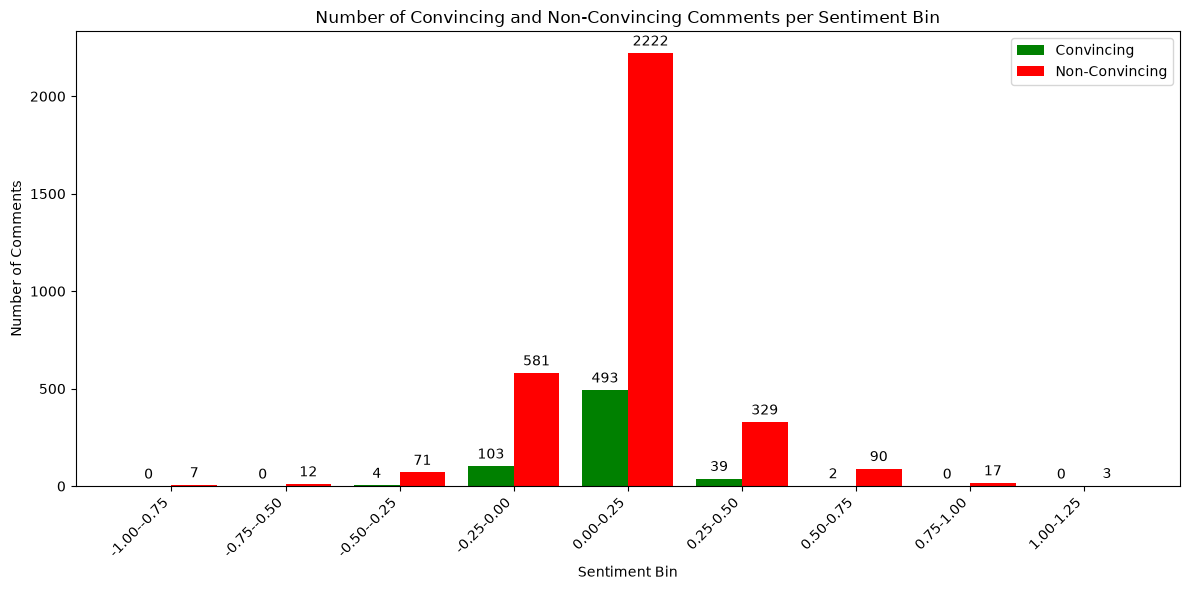

In [14]:
plot_feature('sentiment', 'Sentiment', 0.25)

In [15]:
def show_example_comments(feature_name='sentiment'):
  # Find 3 comments with minimal sentiment
  min_sentiment_comments = comments_df.nsmallest(3, feature_name)
  for index, row in min_sentiment_comments.iterrows():
      print(f"Minimal Sentiment Comment (Sentiment: {row[feature_name]:.2f}):")
      print(f"  Thread Text: {row['thread_text']}")
      print(f"  Final Comment: {row['final_comment']}")
      print("-" * 20)

  # Find 3 comments with maximal sentiment
  max_sentiment_comments = comments_df.nlargest(3, feature_name)
  for index, row in max_sentiment_comments.iterrows():
      print(f"Maximal Sentiment Comment (Sentiment: {row[feature_name]:.2f}):")
      print(f"  Thread Text: {row['thread_text']}")
      print(f"  Final Comment: {row['final_comment']}")
      print("-" * 20)

In [16]:
show_example_comments()

Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: nan
  Final Comment: If noone can decide what is evil then there's nothing evil about schadenfreude
--------------------
Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: nan
  Final Comment: You're looking for r/TrueUnpopularOpinion. Some shocking opinions, but that's the nature of the beast.
--------------------
Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: nan
  Final Comment: Thats probably the worst example ever
--------------------
Maximal Sentiment Comment (Sentiment: 1.00):
  Thread Text: nan
  Final Comment: I wouldn’t have thought of that, but I feel it captures the sentiment perfectly.
--------------------
Maximal Sentiment Comment (Sentiment: 1.00):
  Thread Text: What would be the alternative?  An anarchosyndicalist commune, with someone taking turns to act as a sort of executive officer of the week?  


  Final Comment: > What would be the alternative? An anarchosyndicalist commune, wit

The TextBlob way of identifying the sentiment is based on scoring each word in the text and taking the average score. This approach is less suitable for texts as long as ours. As we can see in the example texts, the sentiment is not identified very well, so we will try a more sophisticated approach, the VADER module.

In [17]:
comments_df = comments_df.drop(columns=['sentiment'])  # drop the TextBlob attempt entirely - not accurate enough to keep, VADER's sentiment_vader replaces it


### VADER module

In [1]:
!pip install vaderSentiment

  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [18]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyzer.polarity_scores(text)['compound']

In [19]:
comments_df["sentiment_vader"] = (comments_df['thread_text'].fillna("") + "\n" + separator_token + "\n" + comments_df['final_comment']).apply(get_sentiment)

comments_df.describe()

,is_convincing,sentiment_vader
count,3973.000000,3973.000000
mean,0.161339,0.143824
std,0.367890,0.691135
min,0.000000,-0.999900
25%,0.000000,-0.504000
50%,0.000000,0.238200
75%,0.000000,0.828600
max,1.000000,0.999700


In [20]:
show_example_comments('sentiment_vader')

Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: Just wanted to chime in with a tiny part. If your living conditions weren't great, or even good, that doesn't give you the right to take it out on people.

I'm a child of war and as shocking that may sound to someone - it gives zero free passing in court. Having PTSD from it is a different thing, but even in cases where someone with PTSD commits a crime he's still held accountable.

Living in a war zone as a child does affect you, but it's not a free pass for being an ass.
[SEP]
He wasn't just *"walking around angry"*.

He had a bat. 

He waited to *be attacked*.

He was ready to ~~hurt~~ kill *any black man* for something one (maybe!) did.

He did it for a *whole week*.


That's really calculated and not something irrational he did while angry. He was making sure that *when* he kills **random black person** it will be said persons fault and LN would play it as self defence. 

Growing up in a war zone does fuck you up, but th

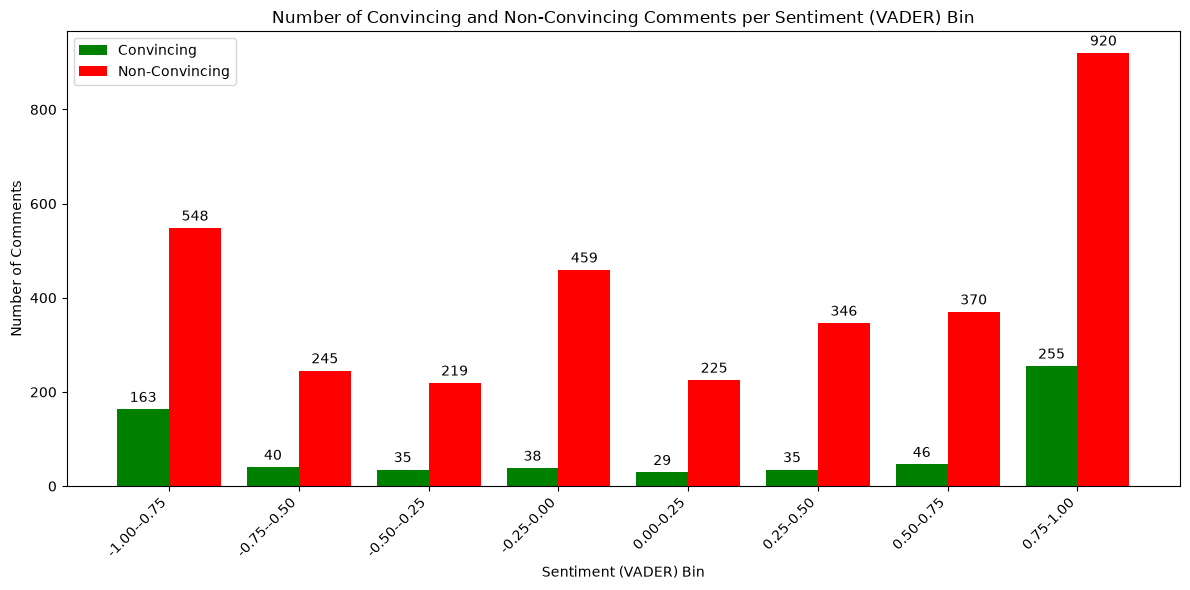

In [21]:
plot_feature('sentiment_vader', 'Sentiment (VADER)', 0.25)

At first glance, it looks like the most convincing comments tend to be either very positive or very negative, while more neutral sentiment corresponds to fewer convincing comments.

The non-convincing comments show a similar pattern: most are scored as very positive, yet were not convincing — which seems counter-intuitive.

Taken at face value, this suggests there's no clean, direct relationship between VADER's sentiment score and whether a comment is convincing.

We're not happy with these results. Looking at the actual examples, VADER is conflating negative *topic* with negative *tone*: the lowest-scored comments are calm, reasoned discussions of dark subjects (racism, police violence, historical injustice) with no rude or hostile language at all, and one of the highest-scored comments is just a dense technical argument about energy technology, not a "pleasant" style. VADER scores on word-level polarity, so words like *racist*, *kill*, or *threat* pull the score down regardless of how respectfully the author is actually writing.

We'll try an LLM-based approach instead, which can reason about the author's tone in context rather than scoring word-by-word.

In [22]:
untrusted_features.append('sentiment_vader')


### LLM-based sentiment (Gemini)

Instead of scoring word-by-word, ask an LLM to rate the author's tone directly, explicitly separating it from the topic being discussed.

In [24]:
import os
from pathlib import Path
from dotenv import load_dotenv
from google import genai

load_dotenv(Path('../.env'))  # .env file must contain GEMINI_API_KEY
GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')

# 'gemini-flash-latest' is a rolling alias for Google's current-gen flash model — as of 2026-07-14
# it resolves to 'gemini-3.5-flash' (checked via response.model_version). The project originally
# pinned 'gemini-2.5-flash', which is no longer reachable from new API keys/projects (404 NOT_FOUND
# as of 2026-07-14). To revert to that exact older model on a key that still has access, set
# GEMINI_MODEL = 'gemini-2.5-flash'.
GEMINI_MODEL = 'gemini-flash-latest'  # re-used and re-configured identically in the Tone section below
genai_client = genai.Client(api_key=GEMINI_API_KEY)


In [32]:
import time
from google.genai import errors as genai_errors

def generate_content_with_retry(model, contents, max_retries=5, initial_delay=2):
  delay = initial_delay
  for attempt in range(max_retries):
    try:
      return genai_client.models.generate_content(model=model, contents=contents)
    except genai_errors.ServerError:
      if attempt == max_retries - 1:
        raise
      print(f"Gemini overloaded (503), retrying in {delay}s...")
      time.sleep(delay)
      delay *= 2


In [35]:
sentiment_llm_prompt_prefix = """Rate the sentiment of each of the following numbered texts on a scale from -1 (very negative) to 1 (very positive).

Base your score only on the tone and attitude of the person writing (e.g. hostile, dismissive, or rude vs. friendly, respectful, or warm) - NOT on how negative or positive the topic being discussed is. A calm, respectful discussion of a dark or violent topic should score close to neutral, not negative.

Reply with exactly one line per text, in the format "N: score" (matching the numbers below), and nothing else.

Texts:
"""


In [26]:
comments_df['sentiment_llm'] = None


In [36]:
import re

def get_sentiment_llm_batch(rows):
  texts = []
  for row in rows:
    if isinstance(row['thread_text'], str):
      texts.append(row['thread_text'] + "\n" + row['final_comment'])
    else:
      texts.append(row['final_comment'])

  numbered_texts = "\n\n".join(f"{i}:\n{text}" for i, text in enumerate(texts))
  user_prompt = sentiment_llm_prompt_prefix + numbered_texts
  response = generate_content_with_retry(model=GEMINI_MODEL, contents=user_prompt)

  scores = [None] * len(texts)
  for line in response.text.strip().splitlines():
    match = re.match(r'\s*(\d+)\s*[:\-]\s*(-?\d*\.?\d+)', line)
    if match:
      i, score = int(match.group(1)), float(match.group(2))
      if 0 <= i < len(scores):
        scores[i] = score
  return scores


In [ ]:
BATCH_SIZE = 20

pending_index = comments_df[comments_df['sentiment_llm'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a score
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  try:
    scores = get_sentiment_llm_batch([comments_df.loc[i] for i in batch_index])
    for i, score in zip(batch_index, scores):
      comments_df.at[i, 'sentiment_llm'] = score
    comments_df.to_csv('../results/comments_df_sentiment_checkpoint.csv', index=False)
    print(f"scored rows {batch_index[0]}-{batch_index[-1]}")
  except genai_errors.ClientError as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed: {e}")
    print("this looks like a quota error, not a transient one - further batches today would just fail too. stopping; re-run this cell after the quota resets.")
    break
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")


In [46]:
none_count = comments_df['sentiment_llm'].isna().sum()
if none_count == 0:
  print("All entries were classified!")
else:
  print(f"{none_count} entries still need to be classified out of {len(comments_df)}")

comments_df['sentiment_llm'] = pd.to_numeric(comments_df['sentiment_llm'], errors='coerce')
comments_df['sentiment_llm'].describe()


All entries were classified!


count    3973.000000
mean        0.074880
std         0.338943
min        -1.000000
25%        -0.100000
50%         0.100000
75%         0.300000
max         1.000000
Name: sentiment_llm, dtype: float64

## 6.2 Tone (continued from `03.2`)

The RoBERTa-based attempt for this feature is in `03.2_feature_engineering_heavy.ipynb` (it needs a GPU to run in reasonable time). We weren't satisfied with those results (see there for details) and continue here with a Gemini-based approach instead, since that only needs API calls, not GPU.

### Google's Gemini

In [ ]:
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path('../.env'))  # .env file must contain GEMINI_API_KEY
GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')


In [ ]:
from google import genai

genai_client = genai.Client(api_key=GEMINI_API_KEY)
GEMINI_MODEL = 'gemini-flash-latest'  # see the model-choice comment in the Sentiment setup cell above


In [ ]:
# let's try with an example text taken randomly from our data set:
test_text = comments_df.iloc[95]['final_comment']
test_text

In [ ]:
user_prompt_prefix = """Analyze the tone of the following text and classify it as one of the following: Logical, Passionate, Humorous, Sarcastic, Neutral, or Other.
Your answer should be just a single word, which is the tone.
Text:
"""

In [ ]:
user_prompt = user_prompt_prefix + test_text

response = genai_client.models.generate_content(model=GEMINI_MODEL, contents=user_prompt)
classification = response.text.strip()
print(classification)


In [ ]:
comments_df['tone_google'] = None

In [ ]:
def get_tone_from_google_ai(row):
  if isinstance(row['thread_text'], str):
    text = row['thread_text'] + "\n" + row['final_comment']
  else:
    text = row['final_comment']

  user_prompt = user_prompt_prefix + text
  response = generate_content_with_retry(model=GEMINI_MODEL, contents=user_prompt)
  classification = response.text.strip()
  print(f"row {row.name} classified as {classification}")
  return classification


In [ ]:
import time

counter = 0
# this loop can be executed multiple times until all entries were classified
for index, row in comments_df.iterrows():
  if counter == 5:
    time.sleep(3)  # add some sleep so we don't get out of quota
    counter = 0
  if pd.isna(row['tone_google']):  # calculate only if wasn't calculated yet
      comments_df.at[index, 'tone_google'] = get_tone_from_google_ai(row)
      counter += 1

In [ ]:
none_count = comments_df['tone_google'].isna().sum()
if none_count == 0:
  print("All entries were classified!")
else:
  print(f"{none_count} entries still need to be classified out of {len(comments_df)}")

In [ ]:
comments_df['tone_google'].head(20)

In [ ]:
plot_category_histogram(comments_df, 'tone_google', 'Tone')

In [ ]:
def show_tone_examples(tone_label):
  print(f"Example for {tone_label}:")
  print(comments_df[comments_df['tone_google'] == tone_label].iloc[0]['final_comment'])
  print("-" * 20)

show_tone_examples("Humorous")
show_tone_examples("Sarcastic")
show_tone_examples("Passionate")

## 6.4 Rhetorical means
**Rhetorical means** refer to the strategies and techniques used to persuade or influence an audience in communication. They are central to the art of rhetoric and can be categorized into three main types: **ethos**, **pathos**, and **logos**. Together, these rhetorical means form the foundation of persuasive communication.

**Ethos** appeals to the speaker's credibility and character, aiming to establish trust with the audience.

**Pathos** focuses on evoking emotions, such as sympathy or anger, to connect with the audience on a personal level.

**Logos**, on the other hand, relies on logic and reasoning, using facts, statistics, and logical arguments to persuade the audience.

We would like to create feature with the amount of each rhetorical mean in each text.

Empath is an open-source text analysis library that categorizes words into psychologically meaningful themes, allowing users to extract insights about emotions, topics, and rhetorical strategies from text. We will use this library to calculate scores for each rhethorical mean in our data set.

In [ ]:
!pip install empath

In [ ]:
pathos_categories = ['hate', 'cheerfulness', 'aggression', 'envy', 'anticipation', 'fear', 'nervousness', 'horror', 'suffering', 'pride', 'sadness', 'optimism', 'irritability', 'surprise', 'exasperation', 'zest', 'confusion', 'love', 'sympathy', 'rage', 'emotional', 'joy', 'affection', 'shame', 'torment', 'anger', 'disappointment', 'pain', 'timidity', 'negative_emotion', 'positive_emotion', 'contentment']
ethos_categories = ['office', 'occupation', 'government', 'royalty', 'wealthy', 'journalism', 'banking', 'leader', 'independence', 'dominant_heirarchical', 'military', 'dominant_personality', 'science', 'work', 'philosophy', 'law', 'achievement']
logos_categories = ['money', 'medical_emergency', 'crime', 'dispute', 'government', 'school', 'computer', 'college', 'business', 'driving', 'internet', 'programming', 'economics', 'politics', 'technology', 'negotiate', 'payment']

In [ ]:
comments_df['ethos_score'] = None
comments_df['pathos_score'] = None
comments_df['logos_score'] = None

In [ ]:
from empath import Empath
import pandas as pd

lexicon = Empath()

def compute_rhetorical_scores():
  for index, row in comments_df.iterrows():
    if pd.isna(row['ethos_score']) or pd.isna(row['pathos_score']) or pd.isna(row['logos_score']):  # calculate only if wasn't calculated yet
      print(f"Calculating rhethorical means for index {index}")
      if isinstance(row['thread_text'], str):
        text = row['thread_text'] + "\n" + row['final_comment']
      else:
        text = row['final_comment']

      analysis = lexicon.analyze(text, normalize=True)  # Normalize to percentage

      ethos_score = sum(analysis[cat] for cat in ethos_categories)
      pathos_score = sum(analysis[cat] for cat in pathos_categories)
      logos_score = sum(analysis[cat] for cat in logos_categories)

      comments_df.at[index, 'ethos_score'] = ethos_score
      comments_df.at[index, 'pathos_score'] = pathos_score
      comments_df.at[index, 'logos_score'] = logos_score

In [ ]:
compute_rhetorical_scores()

Let's plot the distribution of each rhethorical mean in the dataset:

In [ ]:
plot_feature('ethos_score', 'Ethos', 0.10)
plot_feature('pathos_score', 'Pathos', 0.10)
plot_feature('logos_score', 'Logos', 0.10)

Examples:

In [ ]:
def show_rhethorical_mean_example(feature_name):
  for index, row in comments_df[comments_df[feature_name] > 0.85].iterrows():
    print(f"Example for {feature_name} = {row[feature_name]}:")
    print(row['final_comment'])
    print("-" * 20)
    break

show_rhethorical_mean_example('ethos_score')
show_rhethorical_mean_example('pathos_score')
show_rhethorical_mean_example('logos_score')

We see that the results are not reliable, therefore, we won't include this feature in the final model.

It would have been interesting to try to identify the rhethorical means using LLMs such as Gemini or Chat GPT, but due to time limitations, we will not include this in the current work.

In [ ]:
comments_df = comments_df.drop(columns=['ethos_score', 'pathos_score', 'logos_score'])  # per the note above, these aren't reliable enough to include


## 6.5 Adjective-Adverb Ratio

The **Adjective-Adverb Ratio**, also called the **Descriptive Density Ratio** measures the proportion of adjectives and adverbs in a text relative to the total word count. A higher ratio indicates a more expressive or emotionally charged writing style, while a lower ratio suggests a more concise, factual, and objective tone.

In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm

In [ ]:
import spacy

nlp = spacy.load('en_core_web_sm')

def get_adjective_adverb_ratio(text):
  doc = nlp(text)
  adjectives = [token.text for token in doc if token.pos_ == 'ADJ']
  adverbs = [token.text for token in doc if token.pos_ == 'ADV']
  return len(adjectives) / len(adverbs) if len(adverbs) > 0 else np.inf

In [ ]:
comments_df['adj_adv_ratio'] = None

In [ ]:
do_calc_feature("adj_adv_ratio", get_adjective_adverb_ratio)

In [ ]:
import numpy as np
comments_df['adj_adv_ratio_edited'] = comments_df['adj_adv_ratio'].replace(np.inf, 0)

In [ ]:
comments_df['adj_adv_ratio_edited'].describe()

We want to plot the results. The max result, excluding infinity is 15, so we will replace every instance of infinity by 17.

In [ ]:
comments_df['adj_adv_ratio_edited'] = comments_df['adj_adv_ratio'].replace(np.inf, 17)

In [ ]:
plot_feature('adj_adv_ratio_edited', 'Adjective-Adverb Ratio', 1)

In [ ]:
# Drop the 'adj_adv_ratio' column
comments_df = comments_df.drop('adj_adv_ratio', axis=1)

# Rename 'adj_adv_ratio_edited' to 'adj_adv_ratio'
comments_df = comments_df.rename(columns={'adj_adv_ratio_edited': 'adj_adv_ratio'})


In [ ]:

import numpy as np

max_adj_adv_ratio_row = comments_df.loc[comments_df['adj_adv_ratio'].idxmax()]
print(f"Example for high Adj/Adv ratio ({max_adj_adv_ratio_row['adj_adv_ratio']}):")
print(max_adj_adv_ratio_row['final_comment'])
print("-" * 20)

min_adj_adv_ratio_row = comments_df.loc[comments_df['adj_adv_ratio'].idxmin()]
print(f"Example for low Adj/Adv ratio ({min_adj_adv_ratio_row['adj_adv_ratio']}):")
print(min_adj_adv_ratio_row['final_comment'])
print("-" * 20)


Generally, we can say that:
* High Adjective-to-Adverb Ratio
  * More adjectives than adverbs
  * The text is descriptive and vivid, often used in storytelling and persuasive writing to create strong imagery and appeal to emotions.
  * May indicate a focus on ethos (credibility) and pathos (emotion) by painting a compelling picture.

* Low Adjective-to-Adverb Ratio
  * More adverbs than adjectives
  * The text is action-driven and dynamic, emphasizing how actions are performed, often found in arguments, speeches, or instructional writing.
  * May indicate a focus on logos (logical reasoning) and pathos (emotional appeal) by emphasizing how actions happen.

* Balanced Ratio
  * More or less the same amount of adjectives and adverbs
  * The text is neutral and precise, commonly seen in academic, formal, or news writing, aiming for a mix of credibility, logic, and emotional appeal.
  * May indicate a mix of ethos (credibility), logos (logic), and pathos (emotion) in persuasion.



We see that in our dataset, the texts tend to have high ratio of Adjective-to-Adverb.

## 6.6 Readability

Readability is a crucial feature in the feature engineering of convincing and non-convincing texts because it directly impacts how easily the audience can understand and engage with the message. A highly readable text is often more persuasive, as it allows the reader to quickly grasp the key points and emotional appeals without feeling overwhelmed or lost in complex language.

One of the widely used metrics for estimating readability is the **Flesch-Kincaid Readability Tests**.

The **Flesch-Kincaid Readability Tests** provide a score based on sentence length and word complexity, with the result indicating the U.S. school grade level required to understand the text. A lower score suggests a more accessible text, which is often more persuasive.

We will calculate:
* Flesch-Kincaid Grade Level: This score gives an approximation of the U.S. school grade level needed to understand the text. A higher value means more complex language.
* Flesch Reading Ease: This score indicates how easy the text is to read. Higher values (above 60) indicate easier text, while lower values suggest more complex, harder-to-read text.

In [ ]:
!pip install textstat

### Flesh Kincaid Grade Level

In [ ]:
comments_df['fk_grade_level'] = None

In [ ]:
import textstat
do_calc_feature("fk_grade_level", lambda text: textstat.flesch_kincaid_grade(text), remove_urls=True)

In [ ]:
comments_df['fk_grade_level'].head()

The datatype is object, we will convert it to a number.

In [ ]:
comments_df['fk_grade_level_converted'] = pd.to_numeric(comments_df['fk_grade_level'], errors='coerce')

In [ ]:
comments_df['fk_grade_level_converted'].describe()

We see that there's an unexpected result of -15 in the minimum, let's inspect the comments that resulted a value below 0:

In [ ]:
comments_df[comments_df['fk_grade_level_converted'] < 0]

We see that these are very short texts with very few syllables, so the result is expected. Let's inspect the distribution.

In [ ]:
plot_feature('fk_grade_level_converted', 'Flesh Kincaid Grade Level', 5)

In [ ]:
max_grade_level_row = comments_df.loc[comments_df['fk_grade_level_converted'].idxmax()]
print(f"Example for high FK grade level ({max_grade_level_row['fk_grade_level_converted']}):")
print(max_grade_level_row['final_comment'])
print("-" * 20)


In [ ]:
comments_df['fk_grade_level'] = comments_df['fk_grade_level_converted']
comments_df.drop(columns=['fk_grade_level_converted'], inplace=True)

### Flesh Kincaid Reading Ease

In [ ]:
comments_df['fk_reading_ease'] = None

In [ ]:
do_calc_feature("fk_reading_ease", lambda text: textstat.flesch_reading_ease(text), remove_urls=True)

In [ ]:
comments_df['fk_reading_ease'].head()

In [ ]:
comments_df['fk_reading_ease'] = pd.to_numeric(comments_df['fk_reading_ease'], errors='coerce')

In [ ]:
comments_df['fk_reading_ease'].describe()

In [ ]:
plot_feature('fk_reading_ease', 'Flesh Kincaid Reading Ease', 20)

In [ ]:
min_row = comments_df.loc[comments_df['fk_reading_ease'].idxmin()]
print(f"Example for very low FK reading ease ({min_row['fk_reading_ease']}):")
print(min_row['final_comment'])
print("-" * 20)


## 6.7 Use of Evidence

The paper, "[Attitude Change on Reddit's Change My View](https://jpriniski.github.io/papers/cogsci-reddit.pdf)," explores how individuals on the Reddit forum **Change My View (CMV)** adjust their beliefs on various topics, particularly focusing on sociomoral issues (e.g., politics, morality) compared to non-sociomoral topics (e.g., humor, fiction).

The studuy includes the code for calculating evidence use in comments. We will adapt the code from their [repo in GitHub](https://github.com/jpriniski/CMV), and execute it on our own dataset, to create the evidence use features.

In [ ]:
extensions = ['http://', 'https://', '.com', '.org', '.gov', 'pdf', '.net', 'www.']

stems = ['data', 'stat', 'statist', 'figur', '%', 'percent', 'averag', 'number', 'amount',
         'thousand', 'million', 'billion', '$', '€', '¥', '£', 'dollar', 'evid', 'info',
         'testimoni', 'conclus', 'document', 'experi', 'experi', 'measur', 'measur', 'report',
         'result', 'census', 'figur', 'plot', 'graph', 'sum', 'total', 'decim', 'digit', 'fraction',
         'numer', 'half', 'share', 'proport', 'capit', 'cash', 'properti', 'salari', 'wage', 'wealth',
         'financ', 'resourc', 'roll', 'treasuri', 'bank', 'deposit', 'exchang', 'safe', 'estim', 'price',
         'price', 'merchandis', 'retail', 'sale', 'cartel', 'invest', 'market', 'deposit', 'document',
         'indic', 'wit', 'affirm', 'corrobor', 'declar', 'good', 'ground', 'token', 'signific', 'probabl',
         'p valu', '<', '=', 'greater', 'equal', 'less', 'rang', 'devi', 'sd', 'mode',
         'median']

import nltk
snow = nltk.stem.SnowballStemmer('english')

def get_evidence_count(text):
    evidence_count = 0
    comment_stemmed = snow.stem(text.lower())

    for word in comment_stemmed.split():
      if any(s == word for s in stems) and not any(e in word for e in extensions):
          evidence_count += 1

    return evidence_count

In [ ]:
comments_df['evidence_count'] = None

In [ ]:
do_calc_feature("evidence_count", get_evidence_count)

In [ ]:
comments_df['evidence_count'].describe()

In [ ]:
comments_df['evidence_count'] = pd.to_numeric(comments_df['evidence_count'])

In [ ]:
comments_df['evidence_count'].describe()

In [ ]:
plot_feature('evidence_count', 'Evidence Count', 3)

In [ ]:
max_row = comments_df.loc[comments_df['evidence_count'].idxmax()]
print(f"Example for high evidence count ({max_row['evidence_count']}):")
print(max_row['thread_text'])
print(max_row['final_comment'])
print("-" * 20)

# ７. The relation between comments and Original Post

We think that it is possible that a correlation between the comments style, tone etc. and the same features for the original post (OP) may be an indicator for the persuasion of a comment.

Therefore, we will create all the features also for the OP, and include them too as input for the model.

Since many of our commnets share the same original post, we will temporarily create a dataframe with the unique OPs. We will calculate the features for these unique values (to save time), and then we will copy these values into the original dataframe.

In [ ]:
op_df = comments_df['original_post'].drop_duplicates()
op_df.reset_index(drop=True, inplace=True)
op_df = pd.DataFrame(op_df)
op_df

## 7.1 Sentiment Analysis

In [ ]:
op_df["sentiment_op"] = op_df['original_post'].apply(get_sentiment)

op_df.describe()

In [ ]:
untrusted_features.append('sentiment_op')  # same distrusted VADER method used for comments' sentiment_vader


## 7.2 Tone

In [ ]:
op_df['tone_google_op'] = None

def get_tone_from_google_ai(row):
  text = row['original_post']
  user_prompt = user_prompt_prefix + text
  response = generate_content_with_retry(model=GEMINI_MODEL, contents=user_prompt)
  classification = response.text.strip()
  print(f"row {row.name} classified as {classification}")
  return classification


In [ ]:
import time

counter = 0
# this loop can be executed multiple times until all entries were classified
for index, row in op_df.iterrows():
  if counter == 5:
    time.sleep(3)  # add some sleep so we don't get out of quota
    counter = 0
  if pd.isna(row['tone_google_op']):  # calculate only if wasn't calculated yet
      op_df.at[index, 'tone_google_op'] = get_tone_from_google_ai(row)
      counter += 1

## 7.4 Adjective-Adverb Ratio

In [ ]:
op_df['adj_adv_ratio_op'] = None

In [ ]:
do_calc_feature_op("adj_adv_ratio_op", get_adjective_adverb_ratio)

In [ ]:
op_df['adj_adv_ratio_op'].describe()

In [ ]:
op_df['adj_adv_ratio_op'].replace(np.inf, 0).describe()

In [ ]:
op_df['adj_adv_ratio_op'] = op_df['adj_adv_ratio_op'].replace(np.inf, 7)

## 7.5 Readability - Grade Level

In [ ]:
op_df['fk_grade_level_op'] = None

import textstat
do_calc_feature_op("fk_grade_level_op", lambda text: textstat.flesch_kincaid_grade(text), remove_urls=True)

## 7.6 Readability - Reading Ease

In [ ]:
op_df['fk_reading_ease_op'] = None

do_calc_feature_op("fk_reading_ease_op", lambda text: textstat.flesch_reading_ease(text), remove_urls=True)

## 7.7 Evidence Use

In [ ]:
op_df['evidence_count_op'] = None

do_calc_feature_op("evidence_count_op", get_evidence_count)

## Save intermediate output for `03.2`

The heavy notebook loads these, adds the GPU-based features, merges `op_df` into `comments_df`, and saves the final `cmv_comments_df.csv`.

In [ ]:
comments_df.to_csv('../results/comments_df_light.csv', index=False)
op_df.to_csv('../results/op_df_light.csv', index=False)

import json
with open('../results/untrusted_features_light.json', 'w') as f:
    json.dump(untrusted_features, f, indent=2)

print(f'Saved comments_df_light.csv ({len(comments_df)} rows), op_df_light.csv ({len(op_df)} rows), untrusted_features_light.json: {untrusted_features}')
